# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Salma Dewi Nataya
- **Email:** winataya.salma@gmail.com
- **ID Dicoding:** CDCC008D6X2435

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Pada pukul berapa rata-rata jumlah peminjaman sepeda mencapai titik tertinggi dalam satu hari selama periode 2011–2012 sehingga dapat digunakan untuk mengidentifikasi jam operasional dengan permintaan tertinggi?
- **Pertanyaan 2**: Bagaimana perbedaan pola rata-rata peminjaman sepeda antara hari kerja (Senin–Jumat) dan akhir pekan (Sabtu–Minggu) selama periode 2011–2012 untuk memahami perubahan perilaku penggunaan sepeda berdasarkan jenis hari?
- **Pertanyaan 3**: Bagaimana pola rata-rata jumlah peminjaman sepeda pada setiap bulan selama periode 2011–2012 untuk mengidentifikasi bulan dengan tingkat penggunaan tertinggi dan terendah?
- **Pertanyaan 4**: Seberapa besar perbedaan rata-rata jumlah peminjaman sepeda per jam berdasarkan kondisi cuaca selama periode 2011–2012, serta bagaimana pengaruh kondisi cuaca terhadap tingkat penggunaan layanan bike sharing?
- **Pertanyaan 5**: Bagaimana proporsi peminjaman sepeda per jam antara pengguna *casual* dan *registered* selama periode 2011–2012 untuk mengidentifikasi karakteristik dan pola penggunaan dari masing-masing tipe pengguna?

## Import Semua Packages/Library yang Digunakan

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df day.csv dan hour.csv

Data yang digunakan adalah data `day.csv` dan `hour.csv` yang tersedia dalam Bike Sharing Dataset. Dalam kasus ini, data `day.csv` disimpan dalam `df_day` dan `hour.csv` disimpan dalam `df_hour`. Setelah data di-*load*, data akan dicek dengan melihat 5 observasi pertama dan statistik deskriptif setiap data.

In [2]:
df_day = pd.read_csv(r"E:\06 cc26\Bike-sharing-dataset\day.csv")
df_hour = pd.read_csv(r"E:\06 cc26\Bike-sharing-dataset\hour.csv")

Lima observasi pertama dan terakhir serta statistik deskriptif data `day.csv` adalah sebagai berikut.

In [3]:
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [8]:
df_day.tail()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796
730,731,2012-12-31,1,1,12,0,1,1,2,0.215833,0.223487,0.577500,0.154846,439,2290,2729


In [4]:
df_day.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Lima observasi pertama dan terakhir serta statistik deskriptif data `hour.csv` adalah sebagai berikut.

In [5]:
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [10]:
df_hour.tail()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61
17378,17379,2012-12-31,1,1,12,23,0,1,1,1,0.26,0.2727,0.65,0.1343,12,37,49


In [6]:
df_hour.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Data mencakup rentang waktu dua tahun (2011–2012) dengan total 17.379 observasi per jam atau 731 observasi per hari. Terdapat perbedaan skala yang signifikan antara rerata jumlah peminjaman per jam (189 unit) dibandingkan dengan rerata harian (4.504 unit) dengan standar deviasi yang cukup tinggi mencapai 1937.211452 untuk peminjaman harian dan 181.387599 untuk peminjaman per jam. Hal ini menunjukkan adanya fluktuasi intensitas peminjaman yang sangat dinamis pada jam-jam tertentu (seperti rush hour) dibandingkan jika hanya melihat data harian.
- Secara statistik, pengguna terdaftar merupakan tulang punggung layanan ini. Rata-rata pengguna terdaftar mencapai 153 orang per jam, jauh melampaui pengguna kasual yang hanya 35 orang per jam.
- Sekitar 68% dari data merupakan hari kerja (workingday). Dengan standar deviasi jumlah peminjaman harian yang cukup besar (1.937 unit), terdapat indikasi kuat bahwa status hari (kerja vs libur) menciptakan pola penggunaan yang berbeda secara kontras, baik dari sisi waktu puncak maupun durasi peminjaman.
- Rata-rata kondisi cuaca berada pada angka 1.42 (skala 1–4), yang berarti mayoritas peminjaman terjadi pada cuaca cerah hingga mendung tipis. Namun, nilai maksimum pada variabel `weathersit` mencapai angka 4 (cuaca ekstrem), yang secara logis akan menjadi outlier negatif dalam data. Penggunaan boxplot akan sangat efektif di sini untuk melihat seberapa ekstrem penurunan jumlah peminjaman saat cuaca memburuk.
- Nilai maksimum peminjaman dalam satu jam mencapai 977 unit, sementara median berada di angka 142 unit. Distribusi yang condong ke kanan (right-skewed) ini menandakan bahwa terdapat jam-jam tertentu yang memiliki lonjakan penggunaan sangat tinggi, yang nantinya akan teridentifikasi melalui area chart pada analisis jam puncak.

### Assessing Data

#### Identifying 'NA' Problem

In [15]:
print(df_day.isnull().sum())
print(df_hour.isnull().sum())

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


**Steps to Take:**
- Tidak ada penanganan yang harus dilakukan.

**Insight:**
- Tidak terdapat data hilang atau *missing value* pada kedua data yang akan digunakan (df_day dan df_hour). Dengan demikian, tidak perlu penanganan.

#### Identifying Duplication Problem

In [16]:
print("Duplicate df_day:", df_day.duplicated().sum())
print("Duplicate df_hour:", df_hour.duplicated().sum())

Duplicate df_day: 0
Duplicate df_hour: 0


**Steps to Take:**
- Tidak ada penanganan yang harus dilakukan.

**Insight:**
- Tidak terdapat data yang terduplikat pada kedua data yang akan digunakan (df_day dan df_hour). Dengan demikian, tidak perlu penanganan.

#### Identifying Invalid Value Problem

In [ ]:
print(df_hour['hr'].unique())        # harus 0–23
print(df_day['season'].unique())     # harus 1–4
print(df_day['weathersit'].unique()) # harus 1–4

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
[1 2 3 4]
[2 1 3]


**Steps to Take:**
- Tidak ada penanganan yang harus dilakukan.

**Insight:**
- Diketahui data jam, jenis musim (*season*), dan cuaca (*weather*) sudah sesuai dan tidak ada data yang di luar *value* seharusnya. Dengan demikian, tidak perlu penanganan.

#### Identifying Outlier Problem

In [18]:
def cek_outlier(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    return len(outliers)

for col in ['cnt', 'casual', 'registered']:
    print(col, cek_outlier(df_day, col))

cnt 0
casual 44
registered 0


**Steps to Take:**
- Mempertahankan data outlier pada variabel casual karena masih merepresentasikan kondisi nyata dan berpotensi memberikan insight penting terkait pola permintaan pengguna.

**Insight:**
- Berdasarkan pengecekan *outlier* menggunakan metode IQR, ditemukan *outlier* pada variabel *casual*, sedangkan variabel *cnt* dan *registered* tidak menunjukkan adanya *outlier*.
Keberadaan *outlier* pada jumlah pengguna casual mengindikasikan adanya lonjakan peminjaman pada kondisi tertentu, seperti akhir pekan, musim liburan, atau kondisi cuaca yang mendukung aktivitas luar ruangan.

#### Identifying Inaccurate Value

In [19]:
(df_day['cnt'] == df_day['casual'] + df_day['registered']).all()

True

**Steps to Take:**
- Tidak ada penanganan yang harus dilakukan.

**Insight:**
- Dilakukan pengecekan terhadap total (*count*). Diketahui seluruh nilai *count* pada data sudah valid dan sesuai dengan jumlah antara pengguna *casual* dan *registered*.

#### Identifying Incomplete Data

In [9]:
# ==========================================
# CEK KELENGKAPAN JAM PER TANGGAL DI df_hour
# ==========================================

df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])
expected_hours = set(range(24))
missing_hour_records = []
for date, group in df_hour.groupby('dteday'):
    
    actual_hours = set(group['hr'].unique())
    missing_hours = expected_hours - actual_hours
    
    if missing_hours:
        missing_hour_records.append({
            'tanggal': date.date(),
            'jam_hilang': sorted(missing_hours)
        })

if len(missing_hour_records) == 0:
    print("Semua tanggal memiliki data lengkap untuk jam 0–23.")
else:
    print("Terdapat tanggal dengan jam yang hilang:\n")
    
    for record in missing_hour_records:
        print(f"Tanggal: {record['tanggal']}")
        print(f"Jam hilang: {record['jam_hilang']}\n")

# ==========================================
# CEK KELENGKAPAN TANGGAL DI df_day
# ==========================================

df_day['dteday'] = pd.to_datetime(df_day['dteday'])
expected_dates = pd.date_range(
    start='2011-01-01',
    end='2012-12-31',
    freq='D'
)
actual_dates = pd.to_datetime(df_day['dteday'])
missing_dates = expected_dates.difference(actual_dates)

if len(missing_dates) == 0:
    print("Semua tanggal dari 2011-01-01 hingga 2012-12-31 tersedia.")
else:
    print("Terdapat tanggal yang hilang:\n")
    
    for date in missing_dates:
        print(date.date())

Terdapat tanggal dengan jam yang hilang:

Tanggal: 2011-01-02
Jam hilang: [5]

Tanggal: 2011-01-03
Jam hilang: [2, 3]

Tanggal: 2011-01-04
Jam hilang: [3]

Tanggal: 2011-01-05
Jam hilang: [3]

Tanggal: 2011-01-06
Jam hilang: [3]

Tanggal: 2011-01-07
Jam hilang: [3]

Tanggal: 2011-01-11
Jam hilang: [3, 4]

Tanggal: 2011-01-12
Jam hilang: [3, 4]

Tanggal: 2011-01-14
Jam hilang: [4]

Tanggal: 2011-01-18
Jam hilang: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

Tanggal: 2011-01-19
Jam hilang: [3]

Tanggal: 2011-01-22
Jam hilang: [5]

Tanggal: 2011-01-23
Jam hilang: [4]

Tanggal: 2011-01-24
Jam hilang: [2]

Tanggal: 2011-01-25
Jam hilang: [3]

Tanggal: 2011-01-26
Jam hilang: [3, 4, 18, 19, 20, 21, 22, 23]

Tanggal: 2011-01-27
Jam hilang: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

Tanggal: 2011-01-28
Jam hilang: [4]

Tanggal: 2011-01-29
Jam hilang: [5]

Tanggal: 2011-01-30
Jam hilang: [6]

Tanggal: 2011-02-01
Jam hilang: [4]

Tanggal: 2011-02-03
Jam hilang: [4]

Tanggal: 2011-02-04
Ja

**Steps to Take:**
- Melakukan penanganan *missing hourly data* menggunakan metode interpolasi berbasis pola waktu yang serupa, yaitu dengan mengisi nilai jam yang hilang menggunakan rata-rata jumlah peminjaman pada jam yang sama dan tanggal dengan karakteristik serupa dalam bulan yang sama.
- Pendekatan ini dipilih karena pola peminjaman sepeda cenderung dipengaruhi oleh waktu operasional dan rutinitas harian sehingga penggunaan referensi jam yang sama dinilai lebih representatif dibandingkan interpolasi linear biasa.
- Memastikan hasil interpolasi tetap berada dalam rentang nilai yang wajar agar tidak menghasilkan estimasi yang terlalu ekstrem.

**Insight:**
- Seluruh tanggal pada periode 1 Januari 2011 hingga 31 Desember 2012 tersedia pada dataset `df_day` sehingga tidak terdapat *missing data* pada tingkat harian.
- Namun, pada dataset `df_hour` ditemukan beberapa tanggal yang tidak memiliki data lengkap untuk seluruh jam (0–23). *Missing hourly data* umumnya hanya terjadi pada beberapa jam tertentu, seperti pukul 02.00–05.00 meskipun terdapat beberapa tanggal dengan jumlah jam hilang yang cukup banyak.
- Ketidaklengkapan data per jam berpotensi memengaruhi analisis pola peminjaman berbasis waktu, khususnya dalam identifikasi jam sibuk (peak hour) dan perbandingan pola harian. Meskipun demikian, karena sebagian besar tanggal tetap memiliki mayoritas data jam yang lengkap, dataset masih dapat digunakan untuk analisis eksploratif dan visualisasi pola umum penggunaan sepeda.

### Cleaning Data

#### Fixing Duplicate and Invalidity Problem

**Insight:**
Tidak ditemukan *duplicate data*, maupun *invalid value* pada dataset `df_day` dan `df_hour`. Dengan demikian, perbaikan lebih lanjut tidak perlu dilakukan.

#### Fixing Outlier Problem

**Insight:**
Berdasarkan pengecekan *outlier* menggunakan metode IQR, ditemukan *outlier* pada pengguna *casual*, sedangkan pengguna *registered* tidak menunjukkan adanya outlier. Keberadaan *outlier* pada jumlah pengguna *casual* mengindikasikan adanya lonjakan peminjaman pada kondisi tertentu, seperti akhir pekan, musim liburan, atau kondisi cuaca yang mendukung aktivitas luar ruangan. Dengan demikian, *outlier* akan dipertahankan.

#### Fixing Incomplete Data Problem

In [ ]:
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])
all_dates = df_hour['dteday'].unique()
all_hours = range(24)
full_index = pd.MultiIndex.from_product(
    [all_dates, all_hours],
    names=['dteday', 'hr']
)

df_hour_full = (
    df_hour
    .set_index(['dteday', 'hr'])
    .reindex(full_index)
    .reset_index()
)

df_hour_full['mnth'] = df_hour_full['dteday'].dt.month
cols_to_impute = [
    'cnt',
    'casual',
    'registered',
    'temp',
    'atemp',
    'hum',
    'windspeed'
]

for col in cols_to_impute:
    
    hourly_month_mean = (
        df_hour_full
        .groupby(['mnth', 'hr'])[col]
        .transform('mean')
    )
    
    df_hour_full[col] = df_hour_full[col].fillna(hourly_month_mean)

categorical_cols = [
    'season',
    'yr',
    'holiday',
    'weekday',
    'workingday',
    'weathersit'
]

for col in categorical_cols:
    
    mode_values = (
        df_hour_full
        .groupby(['mnth', 'hr'])[col]
        .transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    )
    
    df_hour_full[col] = df_hour_full[col].fillna(mode_values)

print(df_hour_full.isnull().sum())
print(df_hour_full.head())

dteday          0
hr              0
instant       165
season          0
yr              0
mnth            0
holiday         0
weekday         0
workingday      0
weathersit      0
temp            0
atemp           0
hum             0
windspeed       0
casual          0
registered      0
cnt             0
dtype: int64
      dteday  hr  instant  season   yr  mnth  holiday  weekday  workingday  \
0 2011-01-01   0      1.0     1.0  0.0     1      0.0      6.0         0.0   
1 2011-01-01   1      2.0     1.0  0.0     1      0.0      6.0         0.0   
2 2011-01-01   2      3.0     1.0  0.0     1      0.0      6.0         0.0   
3 2011-01-01   3      4.0     1.0  0.0     1      0.0      6.0         0.0   
4 2011-01-01   4      5.0     1.0  0.0     1      0.0      6.0         0.0   

   weathersit  temp   atemp   hum  windspeed  casual  registered   cnt  
0         1.0  0.24  0.2879  0.81        0.0     3.0        13.0  16.0  
1         1.0  0.22  0.2727  0.80        0.0     8.0        32.0  

**Insight:** 
- Ditemukan *missing hourly data* pada beberapa tanggal di dataset `df_hour` sehingga dilakukan proses imputasi untuk menjaga kelengkapan data *time series*.
- Proses imputasi dilakukan menggunakan rata-rata nilai pada jam yang sama di bulan yang sama sehingga pola temporal data tetap dipertahankan.
- Setelah imputasi, seluruh variabel utama seperti `cnt`, `casual`, `registered`, `temp`, `hum`, dan `windspeed` tidak lagi memiliki *missing value*. Kolom `instant` masih memiliki *missing value* karena merupakan *identifier* atau indeks data sehingga tidak dilakukan imputasi agar tidak menghasilkan identitas data yang tidak valid.
- Secara keseluruhan, dataset hasil imputasi telah cukup konsisten dan siap digunakan untuk analisis pola peminjaman sepeda berbasis waktu, cuaca, dan tipe pengguna.

## Exploratory Data Analysis (EDA)

### Explore Peak Bike Rental Hours

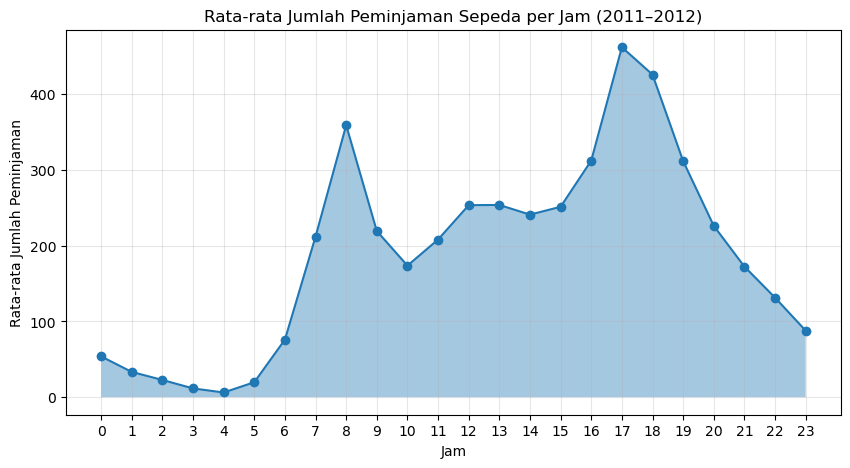

In [16]:
hourly_cnt = df_hour_full.groupby('hr')['cnt'].mean().reset_index()

plt.figure(figsize=(10,5))
plt.fill_between(
    hourly_cnt['hr'],
    hourly_cnt['cnt'],
    alpha=0.4
)
plt.plot(
    hourly_cnt['hr'],
    hourly_cnt['cnt'],
    marker='o'
)

plt.xticks(range(24))
plt.xlabel('Jam')
plt.ylabel('Rata-rata Jumlah Peminjaman')
plt.title('Rata-rata Jumlah Peminjaman Sepeda per Jam (2011–2012)')

plt.grid(alpha=0.3)
plt.show()

In [28]:
hourly_cnt

,hr,cnt
0,0,53.816885
1,1,33.347994
2,2,22.749980
3,3,11.596208
4,4,6.232471
5,5,19.779032
6,6,75.956409
7,7,211.846557
8,8,358.749156
9,9,219.156316


**Insight:**
- Rata-rata jumlah peminjaman sepeda tertinggi terjadi pada pukul 17.00 dengan rata-rata sekitar 462 peminjaman.
- Peningkatan jumlah peminjaman mulai terlihat sejak pukul 06.00 dan mencapai puncak pada jam berangkat serta pulang kerja, yaitu sekitar pukul 08.00 dan 17.00–18.00.
- Jumlah peminjaman terendah terjadi pada dini hari, khususnya pukul 03.00–04.00.
- Pola ini menunjukkan bahwa layanan bike sharing banyak digunakan untuk aktivitas mobilitas harian dan perjalanan kerja (*commuting*).

### Explore Workday vs. Weekend Rental Patterns

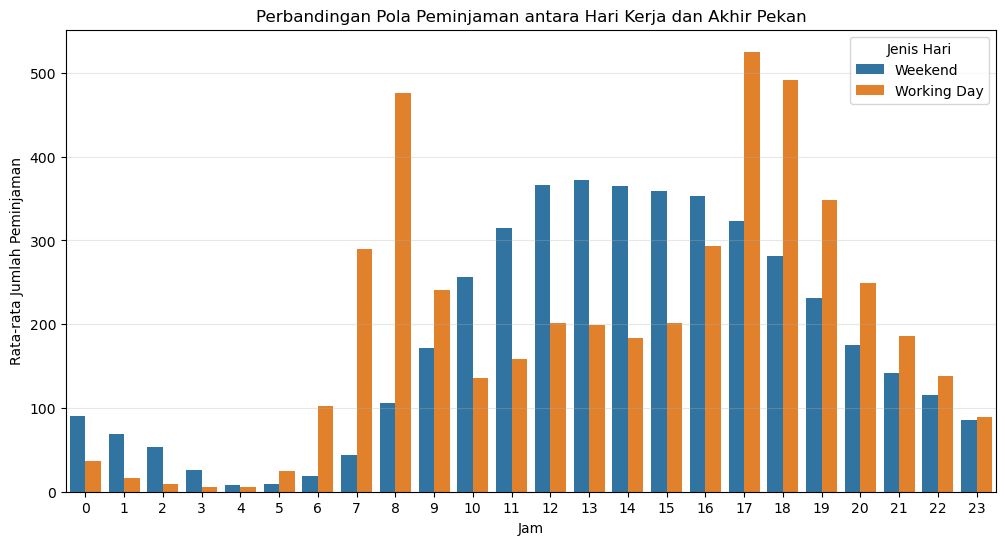

In [17]:
df_hour_full['day_type'] = df_hour_full['workingday'].map({
    1: 'Working Day',
    0: 'Weekend'
})

workingday_pattern = (
    df_hour_full
    .groupby(['hr', 'day_type'])['cnt']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=workingday_pattern,
    x='hr',
    y='cnt',
    hue='day_type'
)

plt.xlabel('Jam')
plt.ylabel('Rata-rata Jumlah Peminjaman')
plt.title('Perbandingan Pola Peminjaman antara Hari Kerja dan Akhir Pekan')

plt.grid(axis='y', alpha=0.3)
plt.legend(title='Jenis Hari')
plt.show()

In [29]:
workingday_pattern

,hr,day_type,cnt
0,0,Weekend,90.800000
1,0,Working Day,36.838609
2,1,Weekend,69.508696
3,1,Working Day,16.747272
4,2,Weekend,53.171053
5,2,Working Day,8.960707
6,3,Weekend,25.775330
7,3,Working Day,5.209977
8,4,Weekend,8.264317
9,4,Working Day,5.317334


**Insight:**
- Pada hari kerja, jumlah peminjaman sepeda meningkat signifikan pada pukul 07.00–09.00 dan 16.00–18.00 dengan puncak tertinggi terjadi pada pukul 17.00.
- Pada akhir pekan, pola peminjaman cenderung lebih stabil dan mencapai puncak pada siang hingga sore hari, terutama sekitar pukul 12.00–15.00.
- Jumlah peminjaman pada dini hari relatif lebih tinggi di akhir pekan dibandingkan hari kerja.
- Perbedaan pola ini menunjukkan bahwa penggunaan sepeda pada hari kerja lebih didominasi kebutuhan transportasi rutin, sedangkan akhir pekan lebih bersifat rekreasional.

### Explore Monthly Bike Rental Patterns

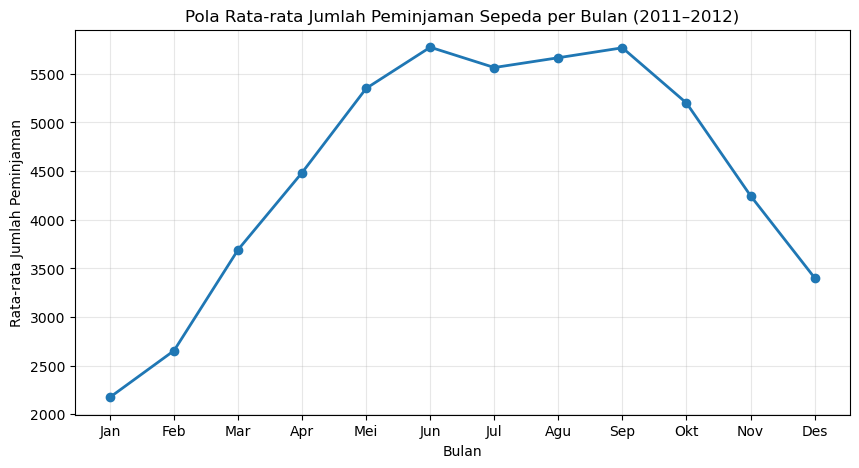

In [ ]:
monthly_cnt = (
    df_day
    .groupby('mnth')['cnt']
    .mean()
)

bulan_labels = [
    'Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun',
    'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des'
]

plt.figure(figsize=(10,5))

plt.plot(
    monthly_cnt.index,
    monthly_cnt.values,
    marker='o',
    linewidth=2
)

plt.xticks(range(1,13), bulan_labels)

plt.xlabel('Bulan')
plt.ylabel('Rata-rata Jumlah Peminjaman')
plt.title('Pola Rata-rata Jumlah Peminjaman Sepeda per Bulan (2011–2012)')

plt.grid(alpha=0.3)

plt.show()

In [31]:
monthly_cnt

mnth
1     2176.338710
2     2655.298246
3     3692.258065
4     4484.900000
5     5349.774194
6     5772.366667
7     5563.677419
8     5664.419355
9     5766.516667
10    5199.225806
11    4247.183333
12    3403.806452
Name: cnt, dtype: float64

**Insight:**
- Jumlah peminjaman sepeda cenderung meningkat dari awal tahun hingga pertengahan tahun.
- Rata-rata peminjaman tertinggi terjadi pada bulan Juli dengan rata-rata sekitar 5.772 peminjaman per hari diikuti bulan September dengan rata-rata sekitar 5.767 peminjaman per hari.
- Jumlah peminjaman terendah terjadi pada bulan Januari dengan rata-rata sekitar 2.176 peminjaman per hari.
- Setelah mencapai puncak pada pertengahan hingga akhir musim panas, jumlah peminjaman kembali menurun menjelang akhir tahun.
- Pola ini mengindikasikan adanya pengaruh musim dan kondisi lingkungan terhadap tingkat penggunaan layanan bike sharing.

### Explore Weather Impact on Bike Rentals

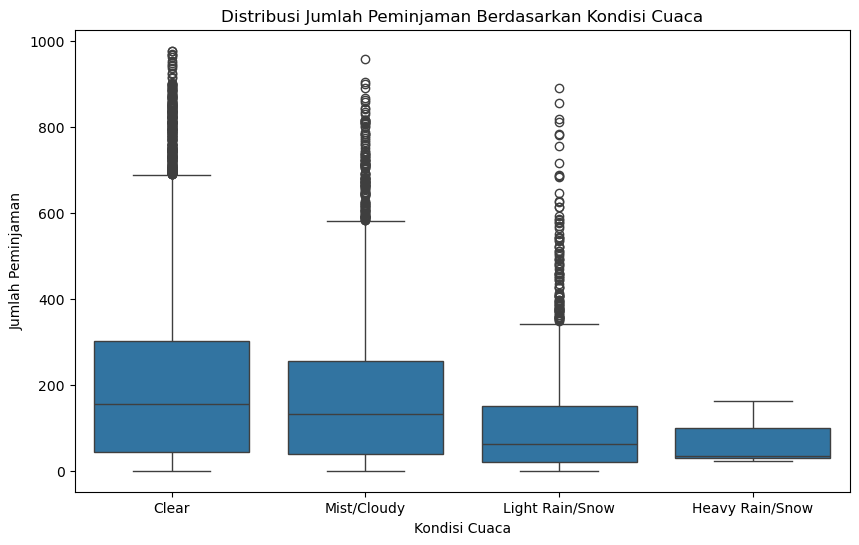

In [ ]:
weather_labels = {
    1: 'Clear',
    2: 'Mist/Cloudy',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}

df_hour_full['weather_category'] = (
    df_hour_full['weathersit']
    .map(weather_labels)
)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_hour_full,
    x='weather_category',
    y='cnt'
)

plt.xlabel('Kondisi Cuaca')
plt.ylabel('Jumlah Peminjaman')
plt.title('Distribusi Jumlah Peminjaman Berdasarkan Kondisi Cuaca')

plt.show()

In [36]:
df_hour_full['weather_category']

0              Clear
1              Clear
2              Clear
3              Clear
4              Clear
            ...     
17539    Mist/Cloudy
17540    Mist/Cloudy
17541          Clear
17542          Clear
17543          Clear
Name: weather_category, Length: 17544, dtype: object

**Insight:**
- Kondisi cuaca cerah memiliki jumlah peminjaman sepeda yang lebih tinggi dibandingkan kondisi cuaca berkabut maupun hujan ringan.
- Pada kondisi cuaca buruk, distribusi jumlah peminjaman cenderung lebih rendah dan memiliki variasi yang lebih kecil.
- Hal ini menunjukkan bahwa kondisi cuaca berpengaruh terhadap keputusan pengguna dalam menggunakan layanan bike sharing. Semakin buruk kondisi cuaca, semakin rendah tingkat penggunaan sepeda.

### Explore User Type Rental Proportions

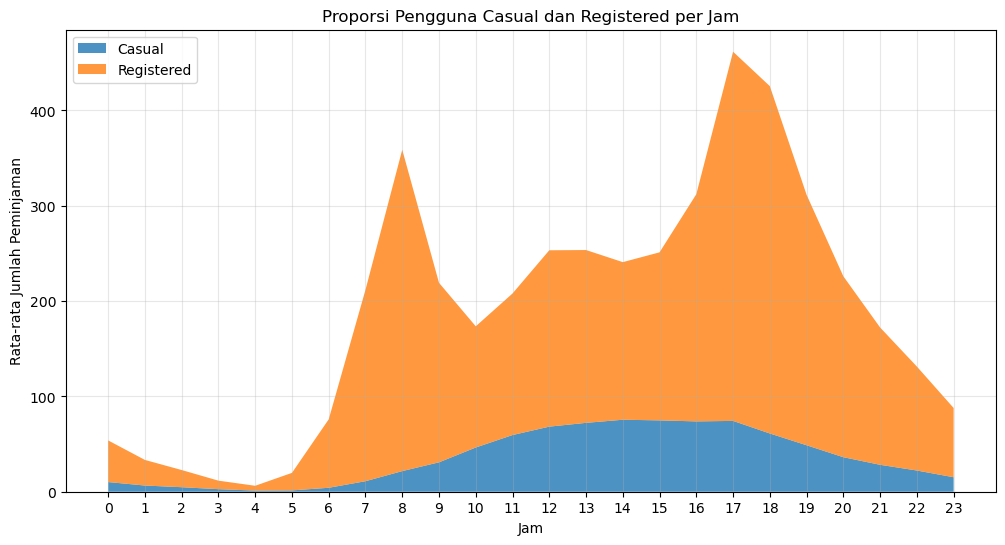

In [ ]:
user_pattern = (
    df_hour_full
    .groupby('hr')[['casual', 'registered']]
    .mean()
)

plt.figure(figsize=(12,6))

plt.stackplot(
    user_pattern.index,
    user_pattern['casual'],
    user_pattern['registered'],
    labels=['Casual', 'Registered'],
    alpha=0.8
)

plt.xticks(range(24))
plt.xlabel('Jam')
plt.ylabel('Rata-rata Jumlah Peminjaman')
plt.title('Proporsi Pengguna Casual dan Registered per Jam')

plt.legend(loc='upper left')
plt.grid(alpha=0.3)

plt.show()

In [37]:
user_pattern

,casual,registered
hr,,
0,10.133768,43.683117
1,6.492196,26.855798
2,4.736934,18.013046
3,2.665764,8.930444
4,1.222549,5.009922
5,1.396625,18.382407
6,4.148100,71.808309
7,11.031236,200.815321
8,21.641632,337.107524


**Insight:**
- Pengguna registered mendominasi jumlah peminjaman sepeda pada hampir seluruh jam dalam sehari.
- Puncak penggunaan *registered users* terjadi pada pukul 08.00 serta 17.00–18.00, yang menunjukkan pola penggunaan untuk aktivitas kerja atau mobilitas rutin.
- Pengguna *casual* memiliki pola penggunaan yang lebih tinggi pada siang hingga sore hari, terutama sekitar pukul 13.00–17.00.
- Perbedaan pola ini menunjukkan bahwa *registered users* cenderung menggunakan layanan secara rutin, sedangkan *casual* users lebih banyak menggunakan layanan untuk aktivitas santai atau rekreasi.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pada pukul berapa rata-rata jumlah peminjaman sepeda mencapai titik tertinggi dalam satu hari selama periode 2011–2012 sehingga dapat digunakan untuk mengidentifikasi jam operasional dengan permintaan tertinggi?

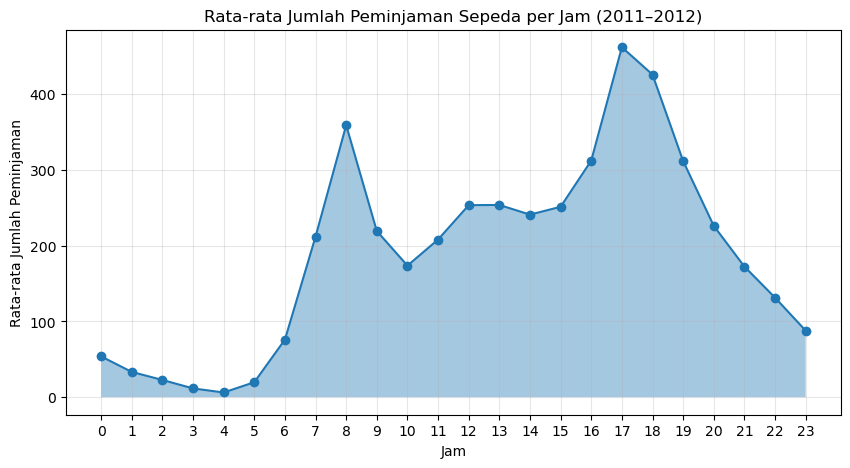

In [ ]:
plt.figure(figsize=(10,5))
plt.fill_between(
    hourly_cnt['hr'],
    hourly_cnt['cnt'],
    alpha=0.4
)
plt.plot(
    hourly_cnt['hr'],
    hourly_cnt['cnt'],
    marker='o'
)

plt.xticks(range(24))
plt.xlabel('Jam')
plt.ylabel('Rata-rata Jumlah Peminjaman')
plt.title('Rata-rata Jumlah Peminjaman Sepeda per Jam (2011–2012)')

plt.grid(alpha=0.3)
plt.show()

**Insight:**
Visualisasi *area chart* yang terbentuk menunjukkan adanya pola penggunaan sepeda yang sangat dipengaruhi oleh aktivitas harian masyarakat. Puncak peminjaman pada pagi dan sore hari mengindikasikan bahwa layanan bike sharing banyak digunakan untuk kebutuhan mobilitas atau commuting. Informasi ini dapat dimanfaatkan untuk mengoptimalkan distribusi sepeda dan kesiapan operasional pada jam sibuk agar ketersediaan layanan tetap terjaga.

### Pertanyaan 2: Bagaimana perbedaan pola rata-rata peminjaman sepeda antara hari kerja (Senin–Jumat) dan akhir pekan (Sabtu–Minggu) selama periode 2011–2012 untuk memahami perubahan perilaku penggunaan sepeda berdasarkan jenis hari?

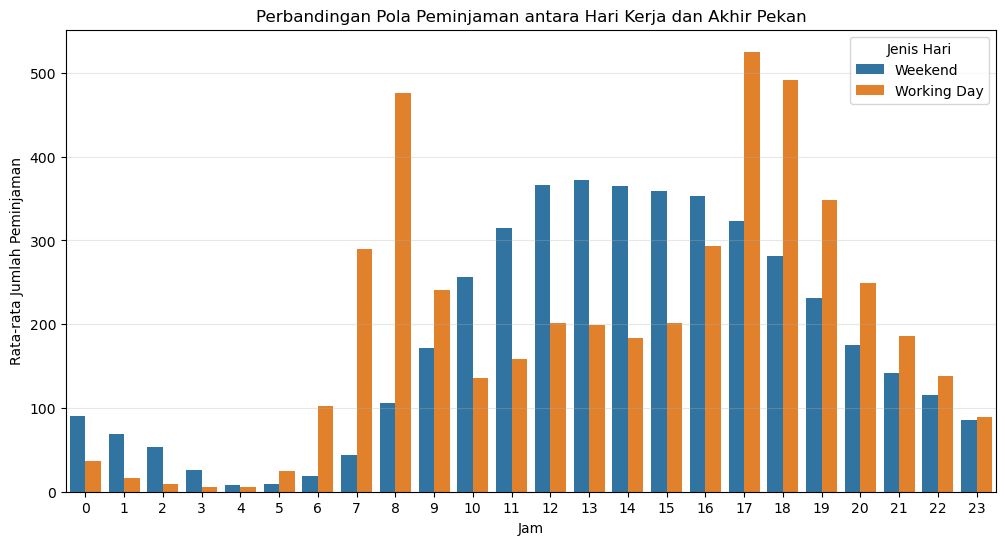

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=workingday_pattern,
    x='hr',
    y='cnt',
    hue='day_type'
)

plt.xlabel('Jam')
plt.ylabel('Rata-rata Jumlah Peminjaman')
plt.title('Perbandingan Pola Peminjaman antara Hari Kerja dan Akhir Pekan')

plt.grid(axis='y', alpha=0.3)
plt.legend(title='Jenis Hari')
plt.show()

**Insight:** 
Visualisasi *bar chart* yang terbentuk menunjukkan adanya perbedaan pola penggunaan sepeda antara hari kerja dan akhir pekan. Pada hari kerja, pola peminjaman didominasi oleh aktivitas perjalanan rutin seperti bekerja atau sekolah, sedangkan pada akhir pekan penggunaan lebih banyak terjadi pada siang hari yang mengarah pada aktivitas rekreasi atau hiburan. Temuan ini dapat membantu pengelola layanan dalam menyesuaikan strategi operasional berdasarkan jenis hari.

### Pertanyaan 3: Bagaimana pola rata-rata jumlah peminjaman sepeda pada setiap bulan selama periode 2011–2012 untuk mengidentifikasi bulan dengan tingkat penggunaan tertinggi dan terendah?

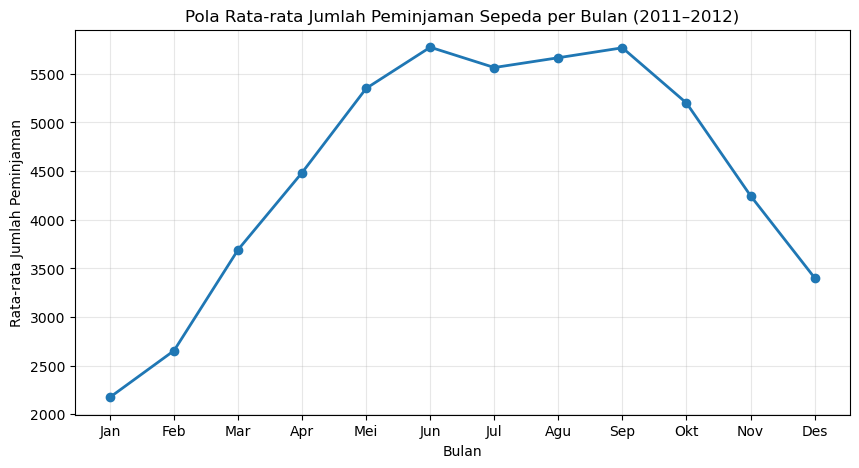

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_cnt.index,
    monthly_cnt.values,
    marker='o',
    linewidth=2
)

plt.xticks(range(1,13), bulan_labels)

plt.xlabel('Bulan')
plt.ylabel('Rata-rata Jumlah Peminjaman')
plt.title('Pola Rata-rata Jumlah Peminjaman Sepeda per Bulan (2011–2012)')

plt.grid(alpha=0.3)

plt.show()

**Insight:**
Visualisasi *line chart* yang terbentuk memperlihatkan adanya pola musiman pada penggunaan layanan bike sharing. Jumlah peminjaman cenderung meningkat pada bulan-bulan dengan kondisi cuaca yang lebih mendukung aktivitas luar ruangan dan menurun pada musim dingin. Informasi ini dapat digunakan untuk mempersiapkan kapasitas layanan, strategi promosi, maupun perencanaan operasional pada periode dengan permintaan tinggi dan rendah.

### Pertanyaan 4: Seberapa besar perbedaan rata-rata jumlah peminjaman sepeda per jam berdasarkan kondisi cuaca selama periode 2011–2012, serta bagaimana pengaruh kondisi cuaca terhadap tingkat penggunaan layanan bike sharing?

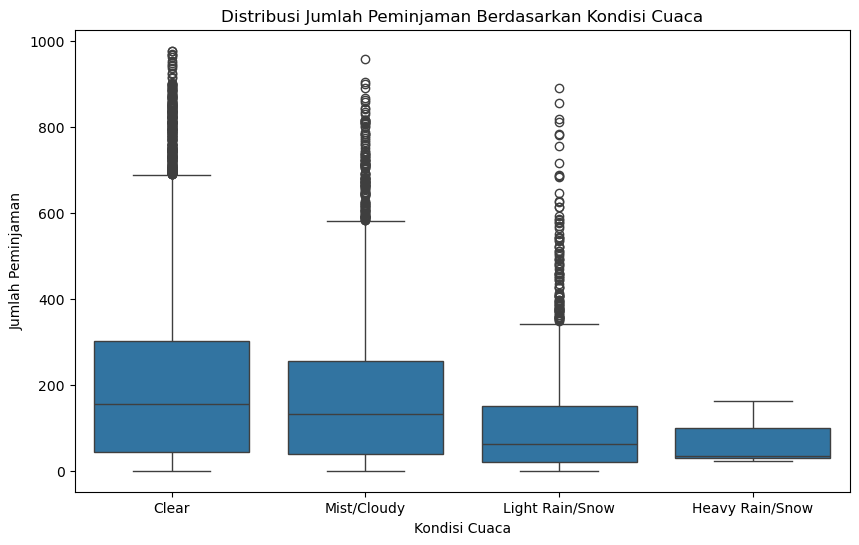

In [33]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_hour_full,
    x='weather_category',
    y='cnt'
)

plt.xlabel('Kondisi Cuaca')
plt.ylabel('Jumlah Peminjaman')
plt.title('Distribusi Jumlah Peminjaman Berdasarkan Kondisi Cuaca')

plt.show()

**Insight:**
Visualisasi *boxplot* yang terbentuk menunjukkan bahwa kondisi cuaca memiliki pengaruh yang cukup signifikan terhadap tingkat penggunaan layanan bike sharing. Cuaca cerah mendorong peningkatan jumlah peminjaman, sedangkan kondisi berkabut atau hujan menyebabkan penurunan penggunaan. Temuan ini dapat membantu pengelola layanan dalam mengantisipasi perubahan permintaan berdasarkan kondisi cuaca dan menyesuaikan strategi operasional maupun promosi layanan.

### Pertanyaan 5: Bagaimana proporsi peminjaman sepeda per jam antara pengguna casual dan registered selama periode 2011–2012 untuk mengidentifikasi karakteristik dan pola penggunaan dari masing-masing tipe pengguna?

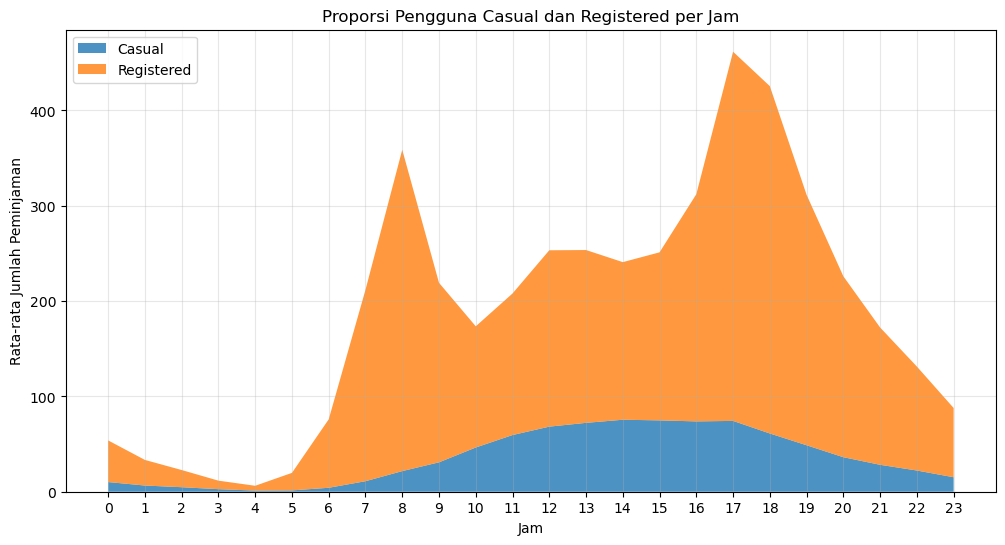

In [34]:
plt.figure(figsize=(12,6))

plt.stackplot(
    user_pattern.index,
    user_pattern['casual'],
    user_pattern['registered'],
    labels=['Casual', 'Registered'],
    alpha=0.8
)

plt.xticks(range(24))
plt.xlabel('Jam')
plt.ylabel('Rata-rata Jumlah Peminjaman')
plt.title('Proporsi Pengguna Casual dan Registered per Jam')

plt.legend(loc='upper left')
plt.grid(alpha=0.3)

plt.show()

**Insight:**
Visualisasi *stacked area chart* yang terbentuk menunjukkan bahwa pengguna registered merupakan kontributor utama terhadap total peminjaman sepeda, khususnya pada jam sibuk kerja. Sementara itu, pengguna casual memiliki pola penggunaan yang lebih merata pada siang hingga sore hari. Perbedaan karakteristik ini dapat dimanfaatkan untuk menyusun strategi layanan dan promosi yang lebih sesuai dengan kebutuhan masing-masing segmen pengguna.

## Analisis Lanjutan (Opsional)

### Hourly Demand Segmentation Analysis

Objektif: Mengelompokkan jam operasional berdasarkan tingkat permintaan peminjaman sepeda untuk membantu optimalisasi operasional layanan.

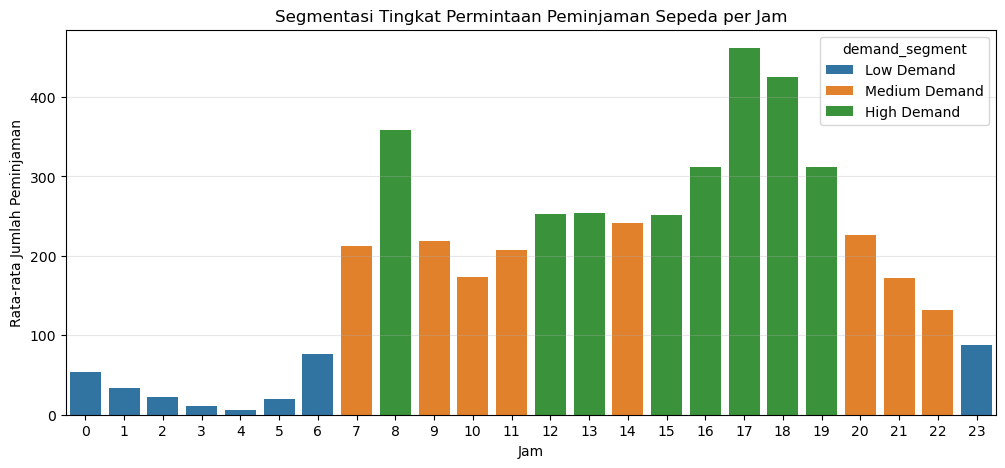

In [38]:
hourly_avg = (
    df_hour_full
    .groupby('hr')['cnt']
    .mean()
    .reset_index()
)

q1 = hourly_avg['cnt'].quantile(0.33)
q2 = hourly_avg['cnt'].quantile(0.66)

def demand_segment(cnt):
    if cnt <= q1:
        return 'Low Demand'
    elif cnt <= q2:
        return 'Medium Demand'
    else:
        return 'High Demand'

hourly_avg['demand_segment'] = (
    hourly_avg['cnt']
    .apply(demand_segment)
)

plt.figure(figsize=(12,5))

sns.barplot(
    data=hourly_avg,
    x='hr',
    y='cnt',
    hue='demand_segment'
)

plt.xlabel('Jam')
plt.ylabel('Rata-rata Jumlah Peminjaman')
plt.title('Segmentasi Tingkat Permintaan Peminjaman Sepeda per Jam')

plt.grid(axis='y', alpha=0.3)

plt.show()

In [43]:
hourly_avg

,hr,cnt,demand_segment
0,0,53.816885,Low Demand
1,1,33.347994,Low Demand
2,2,22.749980,Low Demand
3,3,11.596208,Low Demand
4,4,6.232471,Low Demand
5,5,19.779032,Low Demand
6,6,75.956409,Low Demand
7,7,211.846557,Medium Demand
8,8,358.749156,High Demand
9,9,219.156316,Medium Demand


**Pertanyaan:**
Bagaimana segmentasi tingkat permintaan peminjaman sepeda pada setiap jam selama periode 2011–2012 untuk mengidentifikasi jam operasional dengan aktivitas rendah, sedang, dan tinggi?

**Metode Analisis:**

Analisis dilakukan dengan menghitung rata-rata jumlah peminjaman sepeda (`cnt`) pada setiap jam selama periode 2011–2012. Selanjutnya, dilakukan segmentasi tingkat permintaan menggunakan pendekatan berbasis quantile menjadi tiga kategori, yaitu
- Low Demand,
- Medium Demand, dan
- High Demand.

Segmentasi ini digunakan untuk mengelompokkan jam operasional berdasarkan tingkat aktivitas peminjaman sepeda.

**Insight:**
- Jam dengan kategori High Demand didominasi oleh periode siang hingga sore hari, terutama pukul 08.00, 16.00–19.00, dengan puncak tertinggi pada pukul 17.00.
- Jam dini hari hingga pagi awal, yaitu pukul 00.00–06.00, sebagian besar termasuk dalam kategori Low Demand.
- Kategori Medium Demand banyak muncul pada periode transisi antara jam sibuk dan jam sepi, seperti pukul 07.00, 09.00–11.00, dan malam hari.

### Weather Sensitivity Analysis

Objektif: Mengukur seberapa sensitif penggunaan bike sharing terhadap perubahan kondisi cuaca.

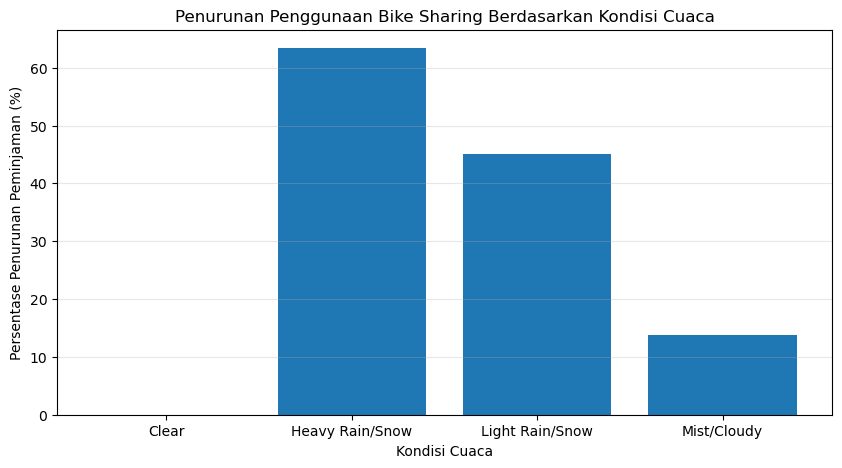

In [40]:
weather_avg = (
    df_hour_full
    .groupby('weather_category')['cnt']
    .mean()
    .reset_index()
)

clear_avg = weather_avg.loc[
    weather_avg['weather_category'] == 'Clear',
    'cnt'
].values[0]

weather_avg['usage_drop_percent'] = (
    (clear_avg - weather_avg['cnt']) / clear_avg
) * 100

plt.figure(figsize=(10,5))

plt.bar(
    weather_avg['weather_category'],
    weather_avg['usage_drop_percent']
)

plt.xlabel('Kondisi Cuaca')
plt.ylabel('Persentase Penurunan Peminjaman (%)')
plt.title('Penurunan Penggunaan Bike Sharing Berdasarkan Kondisi Cuaca')

plt.grid(axis='y', alpha=0.3)

plt.show()

In [45]:
weather_avg

,weather_category,cnt,usage_drop_percent
0,Clear,203.045130,0.000000
1,Heavy Rain/Snow,74.333333,63.390733
2,Light Rain/Snow,111.579281,45.047054
3,Mist/Cloudy,175.165493,13.730759


**Pertanyaan:**
Seberapa besar penurunan rata-rata jumlah peminjaman sepeda pada kondisi cuaca buruk dibandingkan cuaca cerah selama periode 2011–2012?

**Metode Analisis:**

Analisis dilakukan dengan menghitung rata-rata jumlah peminjaman sepeda (`cnt`) pada setiap kategori kondisi cuaca. Selanjutnya, dihitung persentase penurunan penggunaan layanan pada kondisi cuaca tertentu dibandingkan kondisi cuaca cerah sebagai baseline utama.

Persentase penurunan dihitung menggunakan rumus
$$\frac{Mean Clear−Mean Cuaca Tertentu}{Mean Clear} \times 100%.$$

**Insight:**
- Kondisi cuaca cerah menghasilkan rata-rata jumlah peminjaman tertinggi dibandingkan kondisi cuaca lainnya.
- Semakin buruk kondisi cuaca, tingkat penggunaan layanan bike sharing cenderung mengalami penurunan.
- Pengguna bike sharing menunjukkan sensitivitas yang cukup tinggi terhadap perubahan kondisi cuaca.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Pola peminjaman sepeda menunjukkan bahwa permintaan tertinggi terjadi pada jam sibuk, khususnya pada pagi dan sore hari. Hal ini mengindikasikan bahwa layanan *bike sharing* banyak dimanfaatkan sebagai sarana mobilitas harian atau *commuting*.
- **Conclusion pertanyaan 2:** Terdapat perbedaan pola penggunaan sepeda antara hari kerja dan akhir pekan. Hari kerja didominasi oleh aktivitas perjalanan rutin pada jam berangkat dan pulang kerja, sedangkan akhir pekan menunjukkan pola penggunaan yang lebih santai dan terpusat pada siang hingga sore hari.
- **Conclusion pertanyaan 3:** Jumlah peminjaman sepeda dipengaruhi oleh pola musiman. Permintaan cenderung meningkat pada pertengahan tahun dan menurun pada awal maupun akhir tahun, yang menunjukkan bahwa kondisi lingkungan dan musim berpengaruh terhadap intensitas penggunaan layanan *bike sharing*.
- **Conclusion pertanyaan 4:** Kondisi cuaca memiliki pengaruh yang cukup signifikan terhadap tingkat peminjaman sepeda. Cuaca yang lebih baik mendorong peningkatan penggunaan layanan, sedangkan kondisi cuaca buruk menyebabkan penurunan jumlah peminjaman.
- **Conclusion pertanyaan 5:** Pengguna *registered* mendominasi penggunaan layanan bike sharing, terutama pada jam sibuk kerja, sedangkan pengguna *casual* lebih aktif pada siang hingga sore hari. Hal ini menunjukkan adanya perbedaan karakteristik penggunaan antara kedua tipe pengguna.
- **Conclusion analisis lanjutan 1:** Permintaan layanan bike sharing memiliki pola yang tidak merata sepanjang hari. Aktivitas peminjaman sangat terkonsentrasi pada jam-jam tertentu yang berkaitan dengan mobilitas harian masyarakat, khususnya jam berangkat dan pulang kerja. Segmentasi ini membantu mengidentifikasi periode operasional dengan tingkat aktivitas tinggi maupun rendah secara lebih terstruktur.
- **Conclusion analisis lanjutan 2:** Kondisi cuaca merupakan salah satu faktor eksternal yang memengaruhi tingkat penggunaan layanan bike sharing. Cuaca yang kurang mendukung dapat menurunkan minat pengguna dalam menggunakan layanan sehingga permintaan menjadi lebih rendah dibandingkan kondisi cuaca cerah.

**Rekomendasi Action Item:**
- Mengoptimalkan distribusi dan ketersediaan sepeda pada jam sibuk, khususnya pagi dan sore hari, untuk mengantisipasi tingginya permintaan pengguna.
- Menyesuaikan strategi operasional antara hari kerja dan akhir pekan, seperti pengaturan kapasitas sepeda dan lokasi penempatan berdasarkan pola penggunaan pengguna.
- Meningkatkan kesiapan operasional pada bulan-bulan dengan permintaan tinggi melalui penambahan armada atau pemeliharaan fasilitas secara berkala.
- Memanfaatkan informasi cuaca untuk mendukung perencanaan operasional dan strategi promosi, misalnya dengan memberikan insentif penggunaan pada kondisi cuaca tertentu.
- Mengembangkan strategi layanan yang lebih tersegmentasi antara pengguna *casual* dan *registered*, seperti promosi rekreasional untuk *casual users* dan program loyalitas untuk *registered users*.
- Memprioritaskan distribusi dan ketersediaan sepeda pada jam kategori High Demand untuk mengurangi risiko kekurangan unit dan menjadwalkan *maintenance* atau redistribusi sepeda pada jam kategori Low Demand agar tidak mengganggu aktivitas pengguna.
- Mengembangkan sistem monitoring permintaan berbasis waktu secara berkala untuk membantu pengambilan keputusan operasional dan evaluasi performa layanan bike sharing.